In [1]:

##  SCAFFOLD DESIGN SIMULATOR   ##

# Code made by Sami Mohammed

!pip install numpy matplotlib

#Materials library with properties for different scaffold materials

materials = {
    "PLGA": {"pore_size": 150, "porosity": 0.85, "degradation_rate": 12},
    "Collagen": {"pore_size": 100, "porosity": 0.90, "degradation_rate": 4},
    "Alginate": {"pore_size": 200, "porosity": 0.80, "degradation_rate": 8},
    "Hydroxyapatite": {"pore_size": 300, "porosity": 0.70, "degradation_rate": 104},
    "PCL": {"pore_size": 200, "porosity": 0.75, "degradation_rate": 156},
    "Chitosan": {"pore_size": 150, "porosity": 0.82, "degradation_rate": 6},
    "Silk Fibroin": {"pore_size": 200, "porosity": 0.78, "degradation_rate": 20},
    "Gelatin": {"pore_size": 100, "porosity": 0.88, "degradation_rate": 3}
    
}


# Tissue healing times for different tissue types in weeks
tissues = {
    "Skin": 3,
    "Cartilage": 26,
    "Bone": 52,
    "Cardiac muscle": 8,
    "Tendon":52,
    "Nerve":20,
    "Liver":6,
}

# Function to calculate the match score between scaffold degradation rate and tissue healing time
def match_score (degradation_rate, tissue_healing_time):
    difference_ratio = abs(degradation_rate - tissue_healing_time) / tissue_healing_time
    score = 10 - (difference_ratio * 10)
    score = max(0, min(10, score))
    return score

# Loop that runs the match score calculation for each material and tissue type, printing the results
for material_name, material_props in materials.items():
    for tissue_name, healing_weeks in tissues.items():
        score = match_score(material_props["degradation_rate"], healing_weeks)
        

mambajs 0.21.4

Process pip requirements ...

Requirement numpy already handled by conda/micromamba/mamba.
Requirement matplotlib already handled by conda/micromamba/mamba.


In [35]:
# Import libraries for plotting
import numpy as np
import matplotlib.pyplot as plt

score_grid = []

for material_name, material_props in materials.items():
    row = []
    for tissue_name, healing_weeks in tissues.items():
        score = match_score(material_props["degradation_rate"], healing_weeks)
        row.append(score)
    score_grid.append(row)

score_grid = np.array(score_grid)

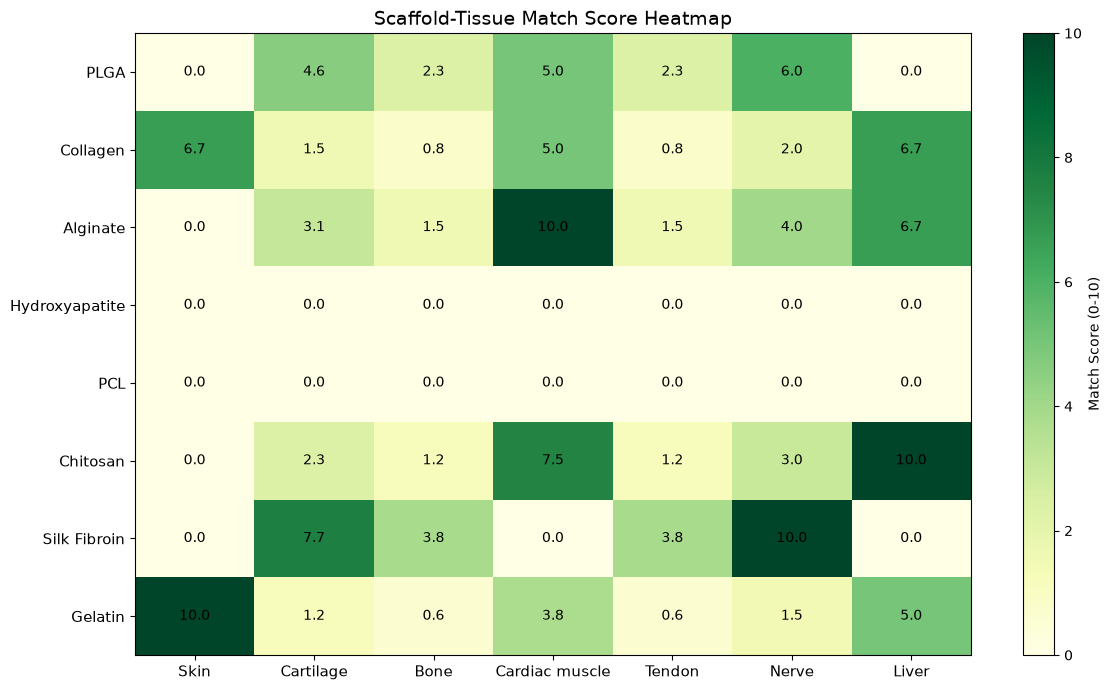

In [36]:
material_names = list(materials.keys())
tissue_names = list(tissues.keys())

# Build score grid
score_grid = []
for material_name, material_props in materials.items():
    row = []
    for tissue_name, healing_weeks in tissues.items():
        score = match_score(material_props["degradation_rate"], healing_weeks)
        row.append(score)
    score_grid.append(row)

score_grid = np.array(score_grid)

# Plot heatmap
plt.figure(figsize=(12, 7))
plt.imshow(score_grid, cmap="YlGn", aspect="auto", vmin=0, vmax=10)
plt.colorbar(label="Match Score (0-10)")
plt.xticks(ticks=range(len(tissue_names)), labels=tissue_names, fontsize=11)
plt.yticks(ticks=range(len(material_names)), labels=material_names, fontsize=11)
plt.title("Scaffold-Tissue Match Score Heatmap", fontsize=14)

for i in range(len(material_names)):
    for j in range(len(tissue_names)):
        plt.text(j, i, f"{score_grid[i, j]:.1f}", ha="center", va="center", fontsize=10, color="black")

plt.tight_layout()
plt.show()


In [ ]:
# Import libraries for the interactive 3D graph
from ipywidgets import interact
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

In [5]:
#3D graph to visualize pore distribution, porosity, and pore size in 3D space

def plot_scaffold(material_name):
    material = materials[material_name]
    porosity = material["porosity"]
    pore_size = material["pore_size"]
    num_pores = int(porosity * 100)

    np.random.seed(42)
    x = np.random.uniform(0, 1, num_pores)
    y = np.random.uniform(0, 1, num_pores)
    z = np.random.uniform(0, 1, num_pores)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, s=pore_size/5, c=z, cmap="YlGn", alpha=0.6)
    ax.set_title(f"{material_name} Scaffold (Porosity: {porosity*100:.0f}%, Pore Size: {pore_size}µm)")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")
    plt.tight_layout()
    plt.show()

# Drop-down menu to select material and render 3D scaffold geometry
interact(plot_scaffold, material_name=list(materials.keys()))

interactive(children=(Dropdown(description='material_name', options=('PLGA', 'Collagen', 'Alginate', 'Hydroxya…

<function __main__.plot_scaffold(material_name)>